# Character naming across the rise of the novel

Three naming categories tagged per character by `scripts/analyze_social_networks.py`:

- **realistic** — first name appears in `data/names/names.txt` (6,881 vernacular English given names from Galbi NE England parish 1530-1830, Cambridge Group reconstitution 1538-1899, and Edinburgh registers 1838-2014).
- **classical** — name ends in `-us`, `-ia`, `-issa`, `-andra`, `-ander`, `-enes`, `-oles`, `-inda`, `-etta`, `-ina`. Captures the Lysander/Andromaque/Clarissa/Pamela tradition.
- **type** — opens with `the`/`a`/`an` or `Possessive's` (e.g. `the Doctor`, `Lady Booby's nephew`). Allegorical or role-only naming.

All three are coarse heuristics, not LLM-classified. The trend is robust because the per-text metric averages over full character lists.

Data: `data/social_networks/social_network_analysis.csv` (output of `analyze_social_networks.py`). Now also includes 8 hand-curated relation-bucket %s (`rel_affiliation_pct`, `rel_kinship_pct`, etc.) from `sn_relation_metacategories.yml`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200

df = pd.read_csv('../data/social_networks/social_network_analysis.csv')
print(f'{len(df):,} texts; {df["year"].min()}-{df["year"].max()}; mean cast = {df["n_chars"].mean():.1f}')
df.head(3)

1,393 texts; 1477-2011; mean cast = 60.0


,year,source,id,title,author,form,mode,n_passages,n_chars,n_rels,...,comp_clustering_resid,comp_centralization_resid,comp_degree_gini_resid,comp_reciprocity_resid,comp_assortativity_resid,rel_density_resid,rel_clustering_resid,rel_reciprocity_resid,dial_reciprocity_resid,evt_centralization_resid
0,1477,_earlyprint/A68341,A68341,For as moche as late by the comau[n]dement of ...,Lefèvre,allegory; romance,chivalric; classical; legendary,160,59,102,...,0.070615,0.208557,-0.037145,0.029871,-0.028096,-0.009076,-0.032087,-0.014971,0.199731,0.065293
1,1481,_eebo_tcp/A10638,A10638,This is the table of the historye of reynart t...,Caxton,fable,?,73,44,60,...,-0.111028,0.060062,0.112579,-0.068354,-0.188670,-0.022304,-0.121057,-0.099467,0.034661,0.009575
2,1484,_eebo_tcp/A05159,A05159,[Here begynneth the booke which the knyght of ...,La Tour Landry,romance; tale,didactic,66,116,63,...,-0.119904,-0.303319,-0.203003,-0.118008,-0.003048,0.008890,-0.073285,-0.178208,-0.064824,-0.079894


## 1. Trend across 1500-1900

Per-text mean of `realistic_pct`, `classical_pct`, `type_pct` in 25-year bins.

In [2]:
BIN = 25
MIN_N = 5
in_range = df[(df['year'] >= 1500) & (df['year'] < 1925)].copy()
in_range['bin'] = (in_range['year'] // BIN * BIN).astype(int)
trend = (in_range.groupby('bin')
         .agg(n=('id', 'count'),
              realistic=('realistic_pct', 'mean'),
              classical=('classical_pct', 'mean'),
              type_name=('type_pct', 'mean'),
              real_se=('realistic_pct', lambda s: s.std() / np.sqrt(len(s))),
              clas_se=('classical_pct', lambda s: s.std() / np.sqrt(len(s))),
              type_se=('type_pct', lambda s: s.std() / np.sqrt(len(s))))
         .query(f'n >= {MIN_N}'))
trend.round(1)

,n,realistic,classical,type_name,real_se,clas_se,type_se
bin,,,,,,,
1500,13,34.7,5.5,20.8,5.1,2.4,6.8
1525,6,19.8,13.4,26.5,6.7,6.7,17.0
1550,21,21.2,7.7,27.5,4.0,2.6,5.9
1575,98,21.5,13.1,23.1,2.1,1.5,2.8
1600,87,22.8,9.4,31.8,2.1,1.3,3.4
1625,69,19.2,16.0,23.2,2.1,2.1,3.1
1650,108,17.7,13.3,30.7,1.7,1.6,3.0
1675,152,24.4,8.5,23.3,1.6,1.0,2.0
1700,44,25.9,7.6,31.8,3.2,1.7,4.5


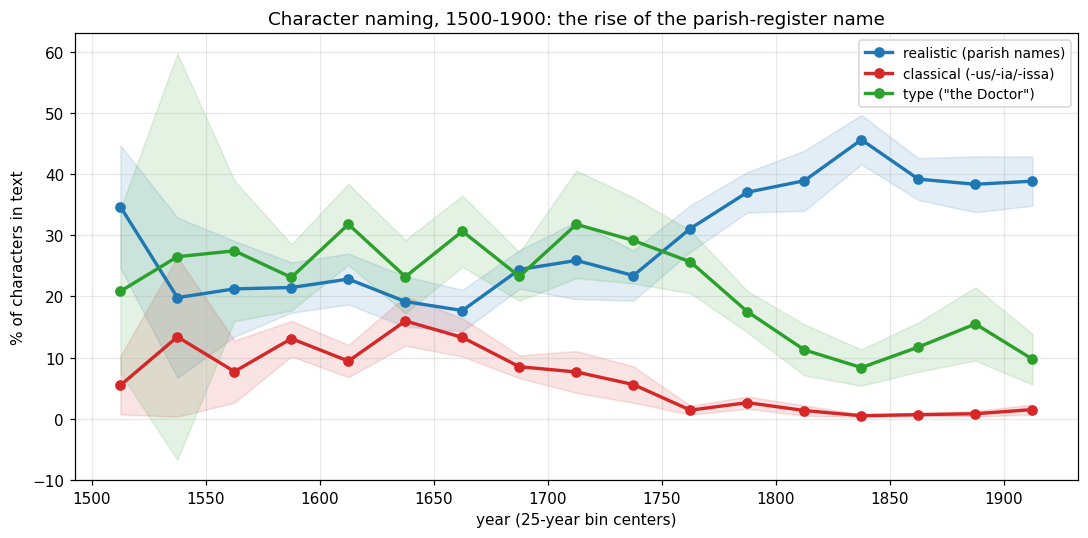

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = trend.index + BIN / 2
for col, se, color, label in [
    ('realistic', 'real_se', '#1f77b4', 'realistic (parish names)'),
    ('classical', 'clas_se', '#d62728', 'classical (-us/-ia/-issa)'),
    ('type_name', 'type_se', '#2ca02c', 'type ("the Doctor")'),
]:
    y = trend[col].values
    ax.plot(x, y, 'o-', color=color, linewidth=2.2, markersize=6, label=label)
    ax.fill_between(x, y - 1.96 * trend[se].values, y + 1.96 * trend[se].values,
                    color=color, alpha=0.13)
ax.set_xlabel(f'year ({BIN}-year bin centers)')
ax.set_ylabel('% of characters in text')
ax.set_title('Character naming, 1500-1900: the rise of the parish-register name')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(MultipleLocator(50))
fig.tight_layout()
fig.savefig('../figures/character_naming_trend.png', bbox_inches='tight')
plt.show()

### Plotnine version: realistic % by decade

Decade-binned LOESS-style trend in plotnine, saved to the Dropbox book figures folder.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_naming_realistic_decade.png


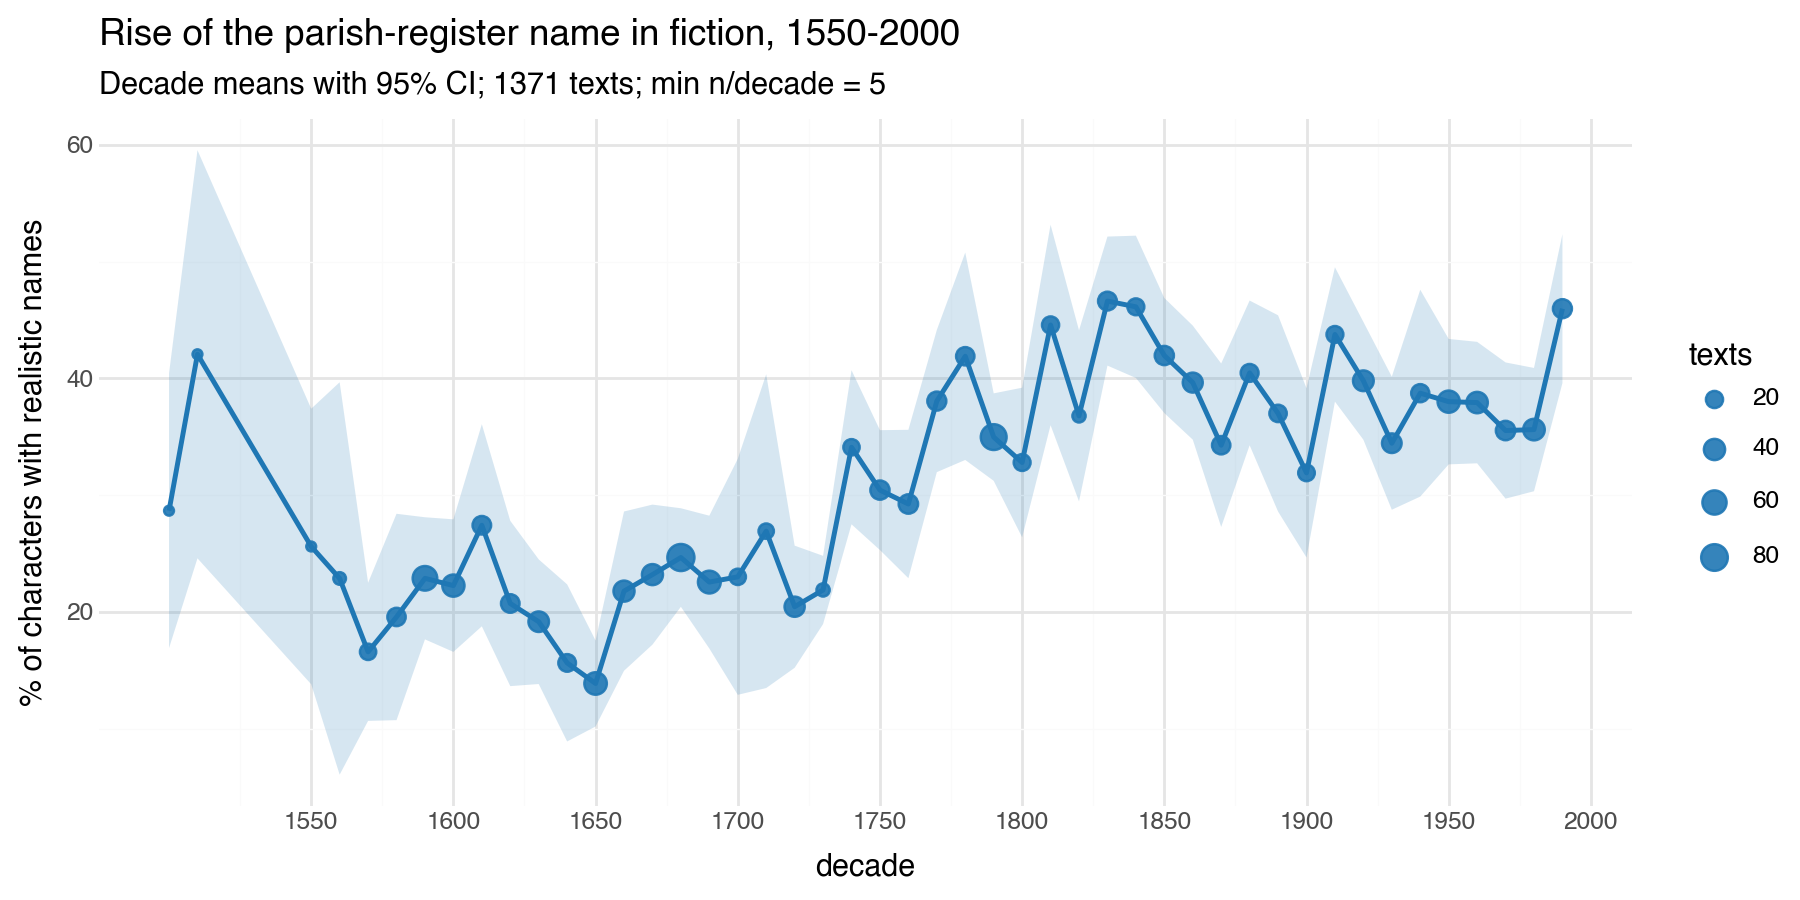

In [4]:
import os
import plotnine as p9

DECADE = 10
MIN_N_DECADE = 5
DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

dec = df[(df['year'] >= 1500) & (df['year'] < 2000)].copy()
dec['decade'] = (dec['year'] // DECADE * DECADE).astype(int)
dec_agg = (dec.groupby('decade')
           .agg(n=('id', 'count'),
                realistic=('realistic_pct', 'mean'),
                se=('realistic_pct', lambda s: s.std(ddof=1) / np.sqrt(len(s))))
           .query(f'n >= {MIN_N_DECADE}')
           .reset_index())
dec_agg['lo'] = dec_agg['realistic'] - 1.96 * dec_agg['se']
dec_agg['hi'] = dec_agg['realistic'] + 1.96 * dec_agg['se']

p = (p9.ggplot(dec_agg, p9.aes(x='decade', y='realistic'))
     + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), alpha=0.18, fill='#1f77b4')
     + p9.geom_line(color='#1f77b4', size=1.0)
     + p9.geom_point(p9.aes(size='n'), color='#1f77b4', alpha=0.9)
     + p9.scale_size_continuous(range=(1.5, 5), name='texts')
     + p9.scale_x_continuous(breaks=range(1550, 2001, 50))
     + p9.labs(
         title='Rise of the parish-register name in fiction, 1550-2000',
         subtitle=f'Decade means with 95% CI; {len(dec)} texts; min n/decade = {MIN_N_DECADE}',
         x='decade',
         y='% of characters with realistic names',
     )
     + p9.theme_minimal()
     + p9.theme(figure_size=(9, 4.5)))

os.makedirs(DROPBOX_FIGS, exist_ok=True)
out_path = os.path.join(DROPBOX_FIGS, 'character_naming_realistic_decade.png')
p.save(out_path, dpi=300, verbose=False)
print(f'Saved to {out_path}')
p

Realistic names roughly double across the 18C inflection (~13% mid-17C → ~28% by 1800). Classical naming collapses from 12-15% to ~1-2% over the same window. Type names fade more gradually. The classical/realistic crossover is around 1700.

## 2. By form

Genre form is the strongest non-temporal predictor — romance vs novel show different naming regimes.

In [5]:
form_rows = []
for _, r in df.iterrows():
    for f in str(r['form']).split('; '):
        form_rows.append({**r.to_dict(), 'form_tag': f.strip()})
fdf = pd.DataFrame(form_rows)
top_forms = fdf['form_tag'].value_counts().head(8).index.tolist()
by_form = (fdf[fdf['form_tag'].isin(top_forms)]
           .groupby('form_tag')
           .agg(n=('id', 'count'),
                realistic=('realistic_pct', 'mean'),
                classical=('classical_pct', 'mean'),
                type_name=('type_pct', 'mean'))
           .loc[top_forms].round(1))
by_form

,n,realistic,classical,type_name
form_tag,,,,
novel,986,33.5,3.7,16.3
romance,348,21.6,14.1,18.9
dialogue,203,34.5,3.5,13.7
tale,148,23.8,9.0,25.1
satire,110,21.3,7.9,34.9
allegory,74,21.1,12.2,22.2
novella,69,19.8,10.0,27.3
rogue fiction,68,20.2,2.1,56.2


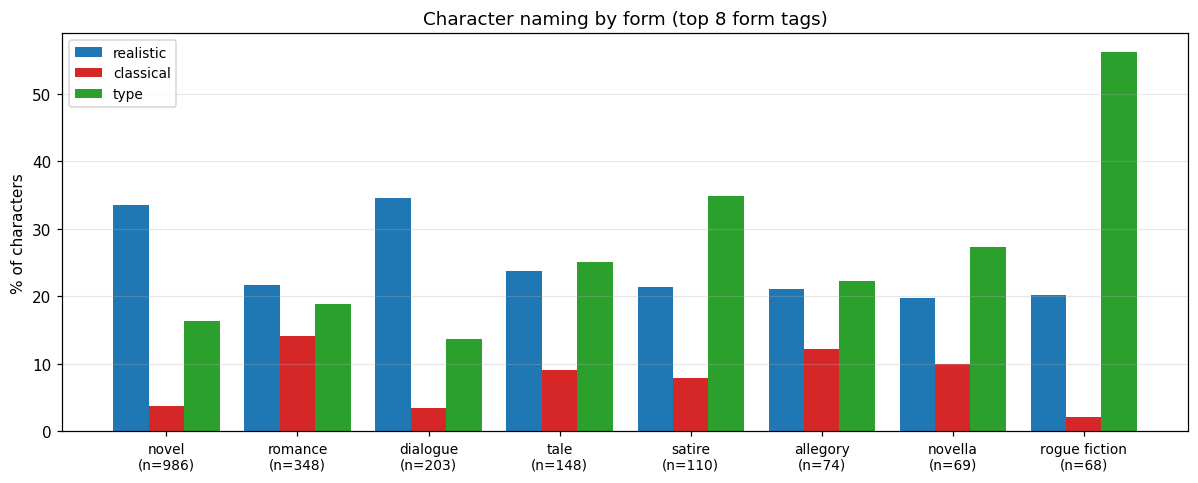

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(by_form))
w = 0.27
ax.bar(x - w, by_form['realistic'], w, color='#1f77b4', label='realistic')
ax.bar(x,     by_form['classical'], w, color='#d62728', label='classical')
ax.bar(x + w, by_form['type_name'], w, color='#2ca02c', label='type')
ax.set_xticks(x)
ax.set_xticklabels([f'{f}\n(n={n})' for f, n in zip(by_form.index, by_form['n'])], fontsize=9)
ax.set_ylabel('% of characters')
ax.set_title('Character naming by form (top 8 form tags)')
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig('../figures/character_naming_by_form.png', bbox_inches='tight')
plt.show()

## 3. Cross with abstractness

Pull text-level abstractness from `abstraction.scores_en` and ask: do abstract texts use more typological / classical names?

In [7]:
import clickhouse_connect
c = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')
ids = df['source'].tolist()
# All SN-corpora texts are English (chadwyck/markmark/earlyprint/ecco_tcp/eebo_tcp),
# so query scores_en directly. (The abstraction.scores view is web-app-only.)
scores = c.query_df(
    "SELECT _id, `Abs-Conc.Median.median` AS raw FROM abstraction.scores_en WHERE _id IN %(ids)s",
    parameters={'ids': ids},
).drop_duplicates('_id')
scores['abs_score'] = -scores['raw']  # + = more abstract
merged = df.merge(scores[['_id', 'abs_score']], left_on='source', right_on='_id', how='left')
have_abs = merged['abs_score'].notna()
print(f'{have_abs.sum()}/{len(merged)} texts with text-level abstractness')
merged[['realistic_pct', 'classical_pct', 'type_pct', 'abs_score']].dropna().corr().round(3)

1393/1393 texts with text-level abstractness


,realistic_pct,classical_pct,type_pct,abs_score
realistic_pct,1.000,-0.369,-0.476,-0.099
classical_pct,-0.369,1.000,-0.148,0.243
type_pct,-0.476,-0.148,1.000,-0.019
abs_score,-0.099,0.243,-0.019,1.000


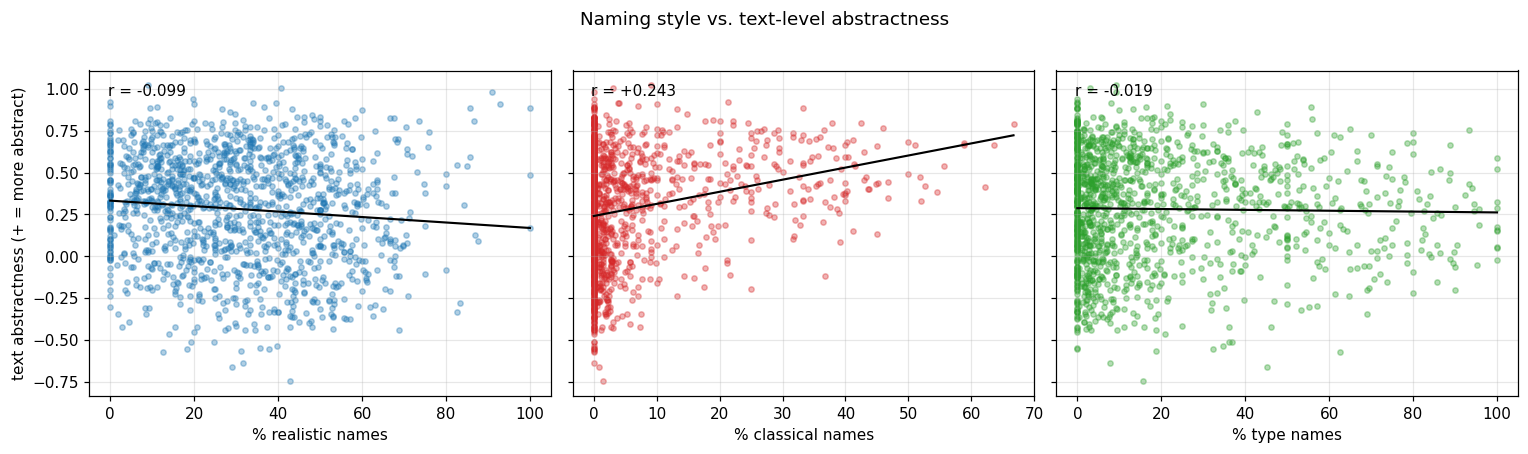

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (col, color, label) in zip(axes, [
    ('realistic_pct', '#1f77b4', '% realistic names'),
    ('classical_pct', '#d62728', '% classical names'),
    ('type_pct',      '#2ca02c', '% type names'),
]):
    sub = merged.dropna(subset=[col, 'abs_score'])
    ax.scatter(sub[col], sub['abs_score'], s=12, alpha=0.35, color=color)
    if len(sub) > 5:
        slope, intercept = np.polyfit(sub[col], sub['abs_score'], 1)
        xs = np.linspace(sub[col].min(), sub[col].max(), 50)
        ax.plot(xs, slope * xs + intercept, color='black', linewidth=1.4)
        r = sub[col].corr(sub['abs_score'])
        ax.text(0.04, 0.96, f'r = {r:+.3f}', transform=ax.transAxes,
                fontsize=10, va='top')
    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('text abstractness (+ = more abstract)')
fig.suptitle('Naming style vs. text-level abstractness', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig('../figures/character_naming_vs_abstractness.png', bbox_inches='tight')
plt.show()

## 4. Feature correlations

How do the 17 main per-text features cluster? Rows/columns ordered by correlation with `year` so the heatmap reads as a temporal gradient (declining features at top, rising features at bottom).

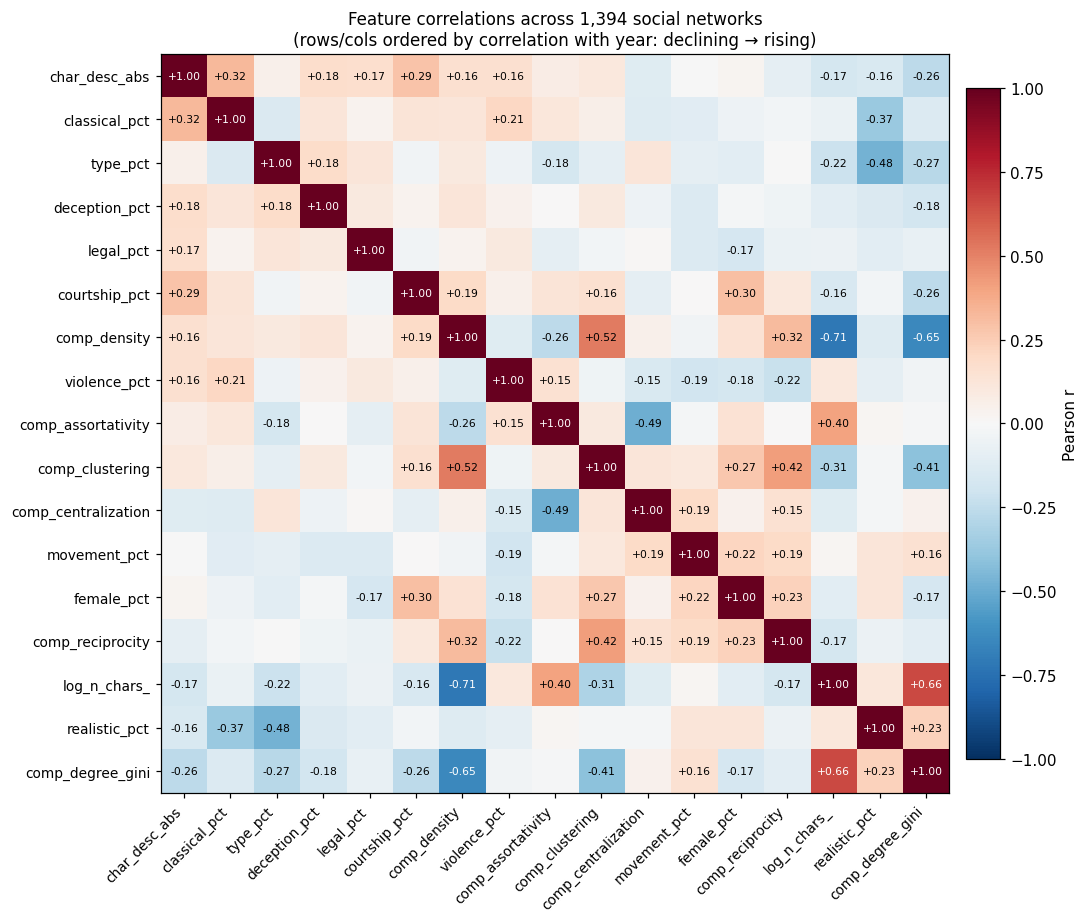


Correlation with year (sorted):
char_desc_abs         -0.582
classical_pct         -0.387
type_pct              -0.288
deception_pct         -0.287
legal_pct             -0.241
courtship_pct         -0.201
comp_density          -0.196
violence_pct          -0.191
comp_assortativity     0.036
comp_clustering        0.063
comp_centralization    0.141
movement_pct           0.162
female_pct             0.172
comp_reciprocity       0.197
log_n_chars_           0.281
realistic_pct          0.351
comp_degree_gini       0.371


In [9]:
# Curated feature subset — naming, demography, events, graph topology, language.
# Sign convention: char_desc_abs is flipped so + = abstract for consistency.
df['char_desc_abs'] = -df['char_desc_conc']
df['log_n_chars_'] = np.log1p(df['n_chars'])

feat_corr = [
    # naming
    'realistic_pct', 'classical_pct', 'type_pct',
    # demographics
    'female_pct',
    # events
    'violence_pct', 'courtship_pct', 'movement_pct', 'deception_pct', 'legal_pct',
    # cast size
    'log_n_chars_',
    # composite graph topology
    'comp_density', 'comp_clustering', 'comp_reciprocity',
    'comp_centralization', 'comp_degree_gini', 'comp_assortativity',
    # description language
    'char_desc_abs',
]
M = df[feat_corr].corr()

# Order by correlation with year (rises first, declines last) — gives the
# heatmap a temporal gradient, separating "C18-rising" from "C18-falling"
year_corr = df[feat_corr + ['year']].corr()['year'].drop('year').sort_values()
order = year_corr.index.tolist()
M = M.loc[order, order]

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(M.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(order, fontsize=9)
for i in range(len(order)):
    for j in range(len(order)):
        v = M.values[i, j]
        if abs(v) >= 0.15:
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.55 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Pearson r')
ax.set_title('Feature correlations across 1,394 social networks\n(rows/cols ordered by correlation with year: declining → rising)',
             fontsize=11)
fig.tight_layout()
fig.savefig('../figures/sn_feature_correlation.png', bbox_inches='tight')
plt.show()
print('\nCorrelation with year (sorted):')
print(year_corr.round(3).to_string())

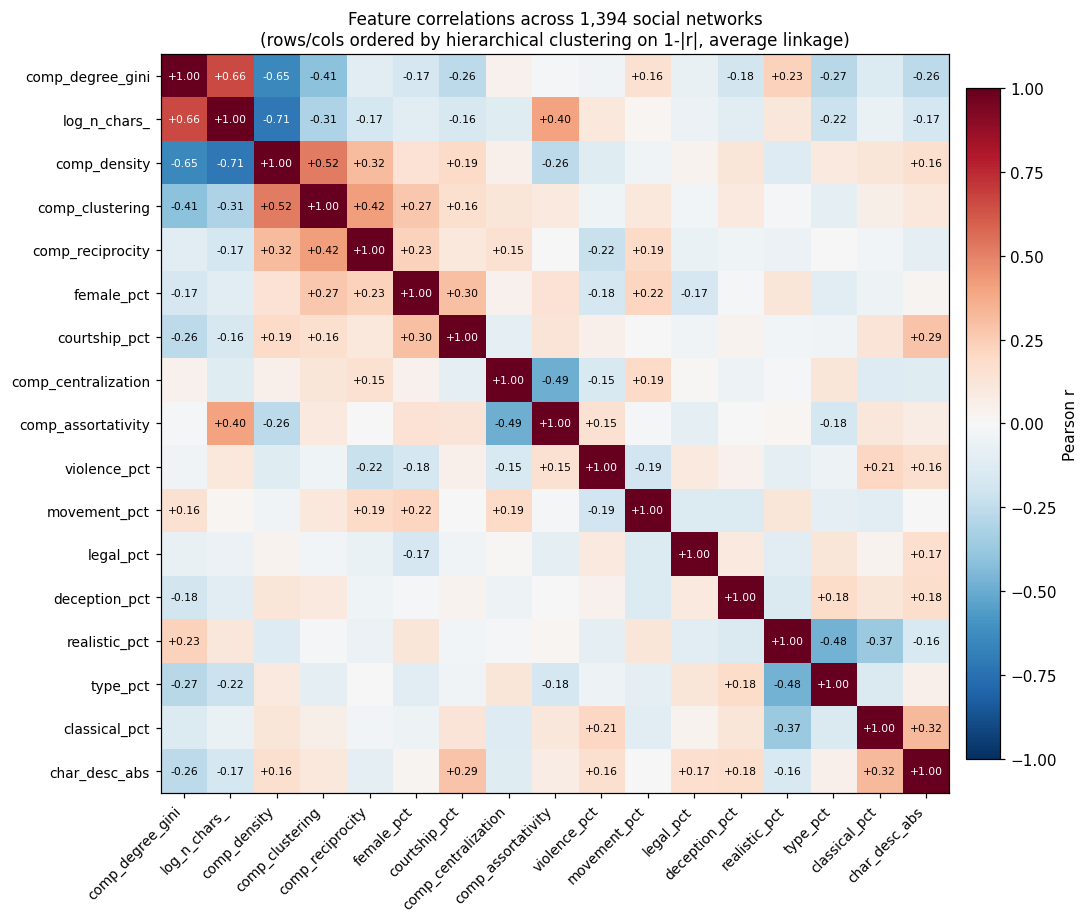


HCluster order:
  comp_degree_gini -> log_n_chars_ -> comp_density -> comp_clustering -> comp_reciprocity -> female_pct -> courtship_pct -> comp_centralization -> comp_assortativity -> violence_pct -> movement_pct -> legal_pct -> deception_pct -> realistic_pct -> type_pct -> classical_pct -> char_desc_abs


In [10]:
# Hierarchical clustering on the same correlation matrix.
# Distance = 1 - |r| so strongly anti-correlated features cluster together
# with strongly correlated ones (both signal "feature pair varies in tandem,
# just opposite signs"). Average linkage keeps the dendrogram interpretable.

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

M_full = df[feat_corr].corr()
D = 1 - np.abs(M_full.values)
np.fill_diagonal(D, 0)
Z = linkage(squareform(D, checks=False), method='average')
order_hc = [feat_corr[i] for i in leaves_list(Z)]
M_hc = M_full.loc[order_hc, order_hc]

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(M_hc.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(order_hc)))
ax.set_yticks(range(len(order_hc)))
ax.set_xticklabels(order_hc, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(order_hc, fontsize=9)
for i in range(len(order_hc)):
    for j in range(len(order_hc)):
        v = M_hc.values[i, j]
        if abs(v) >= 0.15:
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.55 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Pearson r')
ax.set_title('Feature correlations across 1,394 social networks\n(rows/cols ordered by hierarchical clustering on 1-|r|, average linkage)',
             fontsize=11)
fig.tight_layout()
fig.savefig('../figures/sn_feature_correlation_hclust.png', bbox_inches='tight')
fig.savefig(os.path.join(DROPBOX_FIGS, 'sn_feature_correlation_hclust.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print(f'\nHCluster order:\n  {" -> ".join(order_hc)}')

## 5. Which features peak in C18?

For each feature, find the 25-year bin with the highest mean across 1500-1900, and group features by which century the peak falls in. Three families:

- **Peak in 1700s (C18)** — features that *rise into* the 18C novel and decline afterward.
- **Peak in 1500s/1600s** — features in *decline* across the rise of the novel.
- **Peak in 1800s+** — features still *rising* through the realist novel.

Z-scoring within feature lets us overlay them on a single y-axis.

                     peak_bin  peak_z  trough_z  amplitude        peak_group
feature                                                                     
comp_density             1500    2.42     -1.62       4.03        1500s peak
comp_assortativity       1550    1.37     -2.89       4.26        1500s peak
deception_pct            1550    1.43     -1.61       3.04        1500s peak
courtship_pct            1575    1.54     -1.58       3.12        1500s peak
legal_pct                1600    1.49     -1.92       3.42        1600s peak
type_pct                 1600    1.34     -1.66       3.00        1600s peak
classical_pct            1625    2.03     -1.11       3.15        1600s peak
violence_pct             1700    1.73     -1.60       3.33  1700s peak (C18)
comp_clustering          1725    1.75     -2.22       3.98  1700s peak (C18)
comp_centralization      1725    1.25     -2.27       3.52  1700s peak (C18)
char_desc_abs            1775    1.17     -2.16       3.33  1700s peak (C18)

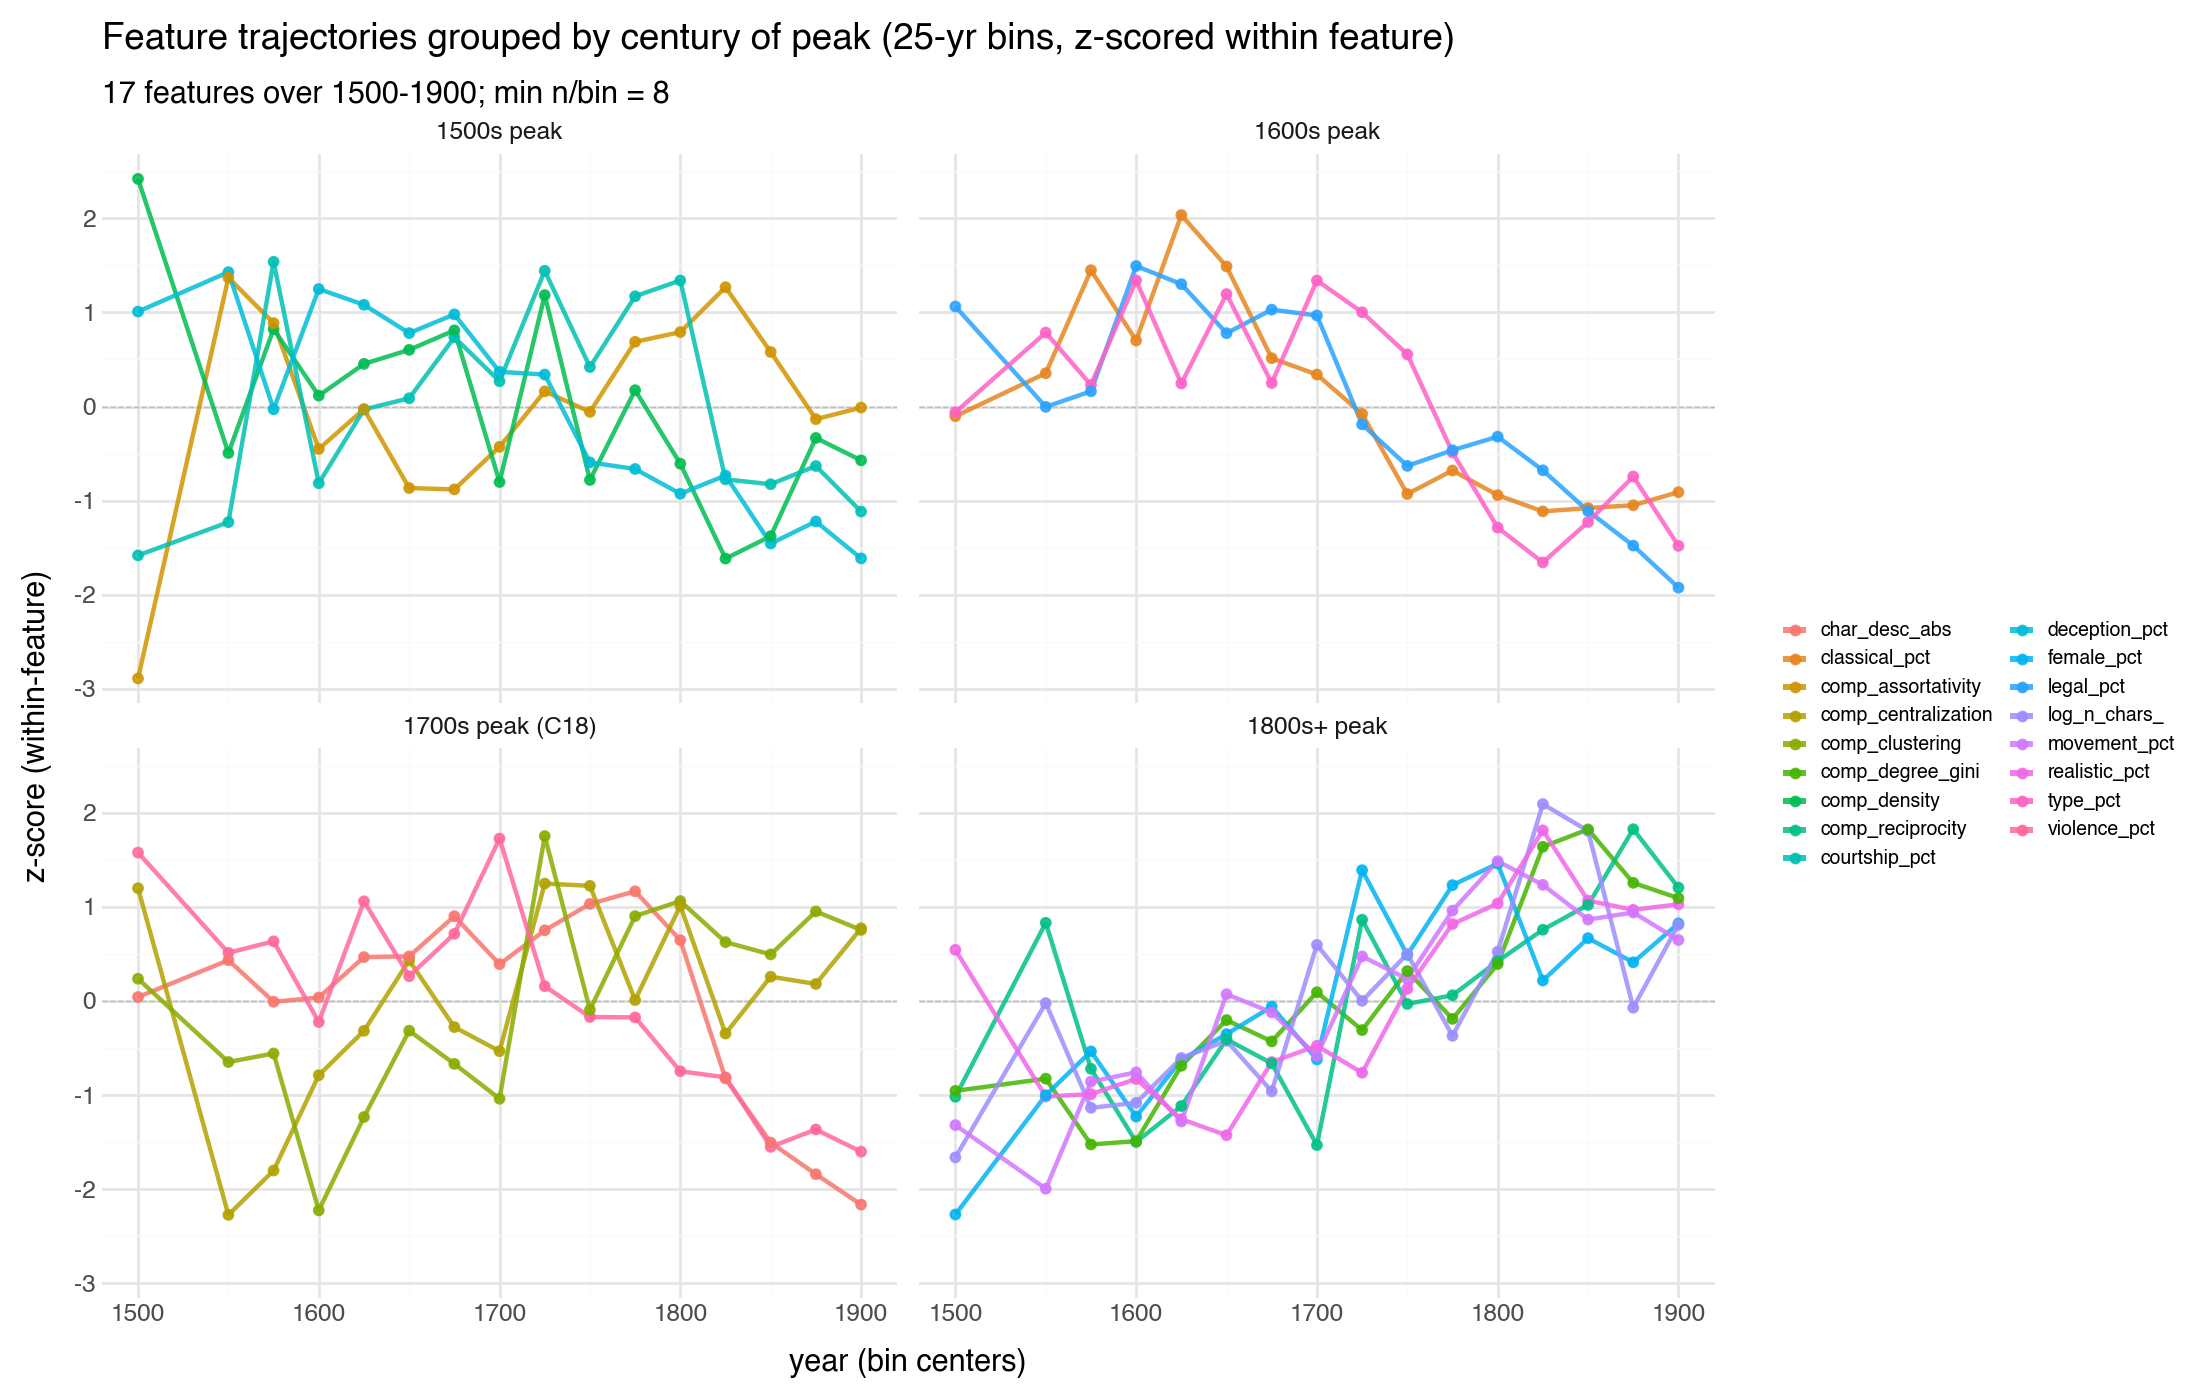

In [11]:
# Bin every feature by 25y; find the bin with peak (max) value over 1500-1900;
# classify by which century the peak falls in. Plot z-scored trends, faceted
# by peak century, to visualize the rise/peak/fall families.

PEAK_BIN = 25
PEAK_MIN_N = 8

peak_df = df[(df['year'] >= 1500) & (df['year'] < 1925)].copy()
peak_df['bin'] = (peak_df['year'] // PEAK_BIN * PEAK_BIN).astype(int)

trend_long = []
for f in feat_corr:
    sub = peak_df[['bin', f]].dropna()
    binned = sub.groupby('bin').agg(n=('bin', 'count'), val=(f, 'mean'))
    binned = binned[binned['n'] >= PEAK_MIN_N].reset_index()
    if len(binned) < 4:
        continue
    binned['z'] = (binned['val'] - binned['val'].mean()) / binned['val'].std(ddof=0)
    binned['feature'] = f
    binned['peak_bin'] = int(binned.loc[binned['val'].idxmax(), 'bin'])
    trend_long.append(binned)

trend_long = pd.concat(trend_long, ignore_index=True)

def peak_century(b):
    if b < 1600: return '1500s peak'
    if b < 1700: return '1600s peak'
    if b < 1800: return '1700s peak (C18)'
    return '1800s+ peak'

trend_long['peak_group'] = trend_long['peak_bin'].map(peak_century)

# Summary table
summary = (trend_long.groupby('feature')
           .agg(peak_bin=('peak_bin', 'first'),
                peak_z=('z', 'max'),
                trough_z=('z', 'min'),
                amplitude=('z', lambda s: s.max() - s.min()))
           .sort_values('peak_bin'))
summary['peak_group'] = summary['peak_bin'].map(peak_century)
print(summary.round(2).to_string())

# Faceted plot, ordered so C18-peaked features stand out
group_order = ['1500s peak', '1600s peak', '1700s peak (C18)', '1800s+ peak']
trend_long['peak_group'] = pd.Categorical(trend_long['peak_group'],
                                          categories=group_order, ordered=True)

p_peak = (p9.ggplot(trend_long, p9.aes(x='bin', y='z', group='feature', color='feature'))
          + p9.geom_hline(yintercept=0, linetype='dashed', color='#bbbbbb', size=0.3)
          + p9.geom_line(size=0.9, alpha=0.85)
          + p9.geom_point(size=1.4, alpha=0.85)
          + p9.facet_wrap('~ peak_group', ncol=2)
          + p9.scale_x_continuous(breaks=range(1500, 1901, 100))
          + p9.labs(
              title=f'Feature trajectories grouped by century of peak ({PEAK_BIN}-yr bins, z-scored within feature)',
              subtitle=f'{len(feat_corr)} features over 1500-1900; min n/bin = {PEAK_MIN_N}',
              x='year (bin centers)',
              y='z-score (within-feature)',
              color='',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(11, 7), legend_position='right',
                     legend_text=p9.element_text(size=7),
                     legend_key_size=8))
p_peak

## 6. Abstractness of character descriptions over time

For each text we pool every character's `descriptions` (short phrases like *"vast Fortune"*, *"matchless Charms"*) and `intro_text` (the framing introductory sentence), then score that pooled text against `Abs-Conc.Median.median`. This is a per-person-language measurement — distinct from text-level abstractness, which averages over narration + dialogue + description alike.

Convention: positive = more abstract.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_descriptions_abstractness_decade.png


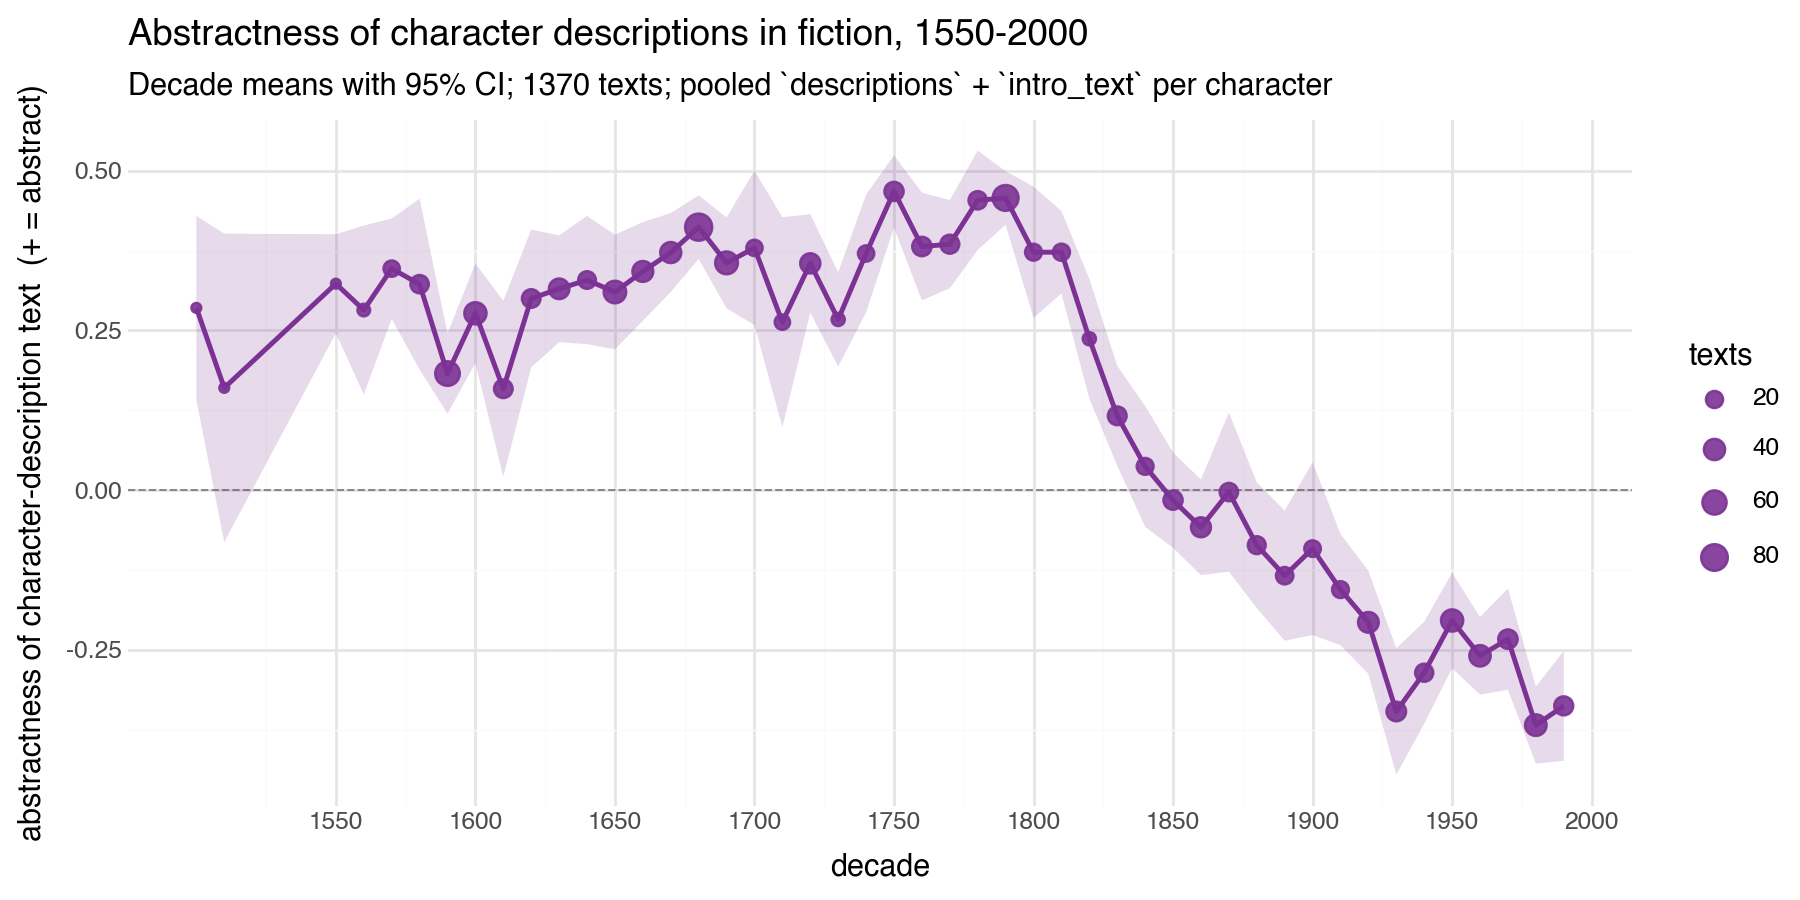

In [12]:
# Decade-binned trend, abstractness convention (+ = abstract)
DECADE_DESC = 10
MIN_N_DESC = 5
desc_in_range = df[(df['year'] >= 1500) & (df['year'] < 2000) & df['char_desc_conc'].notna()].copy()
desc_in_range['decade'] = (desc_in_range['year'] // DECADE_DESC * DECADE_DESC).astype(int)
desc_in_range['desc_abs'] = -desc_in_range['char_desc_conc']

desc_agg = (desc_in_range.groupby('decade')
            .agg(n=('id', 'count'),
                 desc_abs=('desc_abs', 'mean'),
                 se=('desc_abs', lambda s: s.std(ddof=1) / np.sqrt(len(s))))
            .query(f'n >= {MIN_N_DESC}')
            .reset_index())
desc_agg['lo'] = desc_agg['desc_abs'] - 1.96 * desc_agg['se']
desc_agg['hi'] = desc_agg['desc_abs'] + 1.96 * desc_agg['se']

p_desc = (p9.ggplot(desc_agg, p9.aes(x='decade', y='desc_abs'))
          + p9.geom_hline(yintercept=0, linetype='dashed', color='#888888', size=0.4)
          + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), alpha=0.18, fill='#7b3294')
          + p9.geom_line(color='#7b3294', size=1.0)
          + p9.geom_point(p9.aes(size='n'), color='#7b3294', alpha=0.9)
          + p9.scale_size_continuous(range=(1.5, 5), name='texts')
          + p9.scale_x_continuous(breaks=range(1550, 2001, 50))
          + p9.labs(
              title='Abstractness of character descriptions in fiction, 1550-2000',
              subtitle=f'Decade means with 95% CI; {len(desc_in_range)} texts; pooled `descriptions` + `intro_text` per character',
              x='decade',
              y='abstractness of character-description text  (+ = abstract)',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(9, 4.5)))

out_desc = os.path.join(DROPBOX_FIGS, 'character_descriptions_abstractness_decade.png')
p_desc.save(out_desc, dpi=300, verbose=False)
print(f'Saved to {out_desc}')
p_desc

1370 texts with both metrics
  Pearson correlation (per-text): r = +0.868


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_descriptions_vs_text_abstractness.png


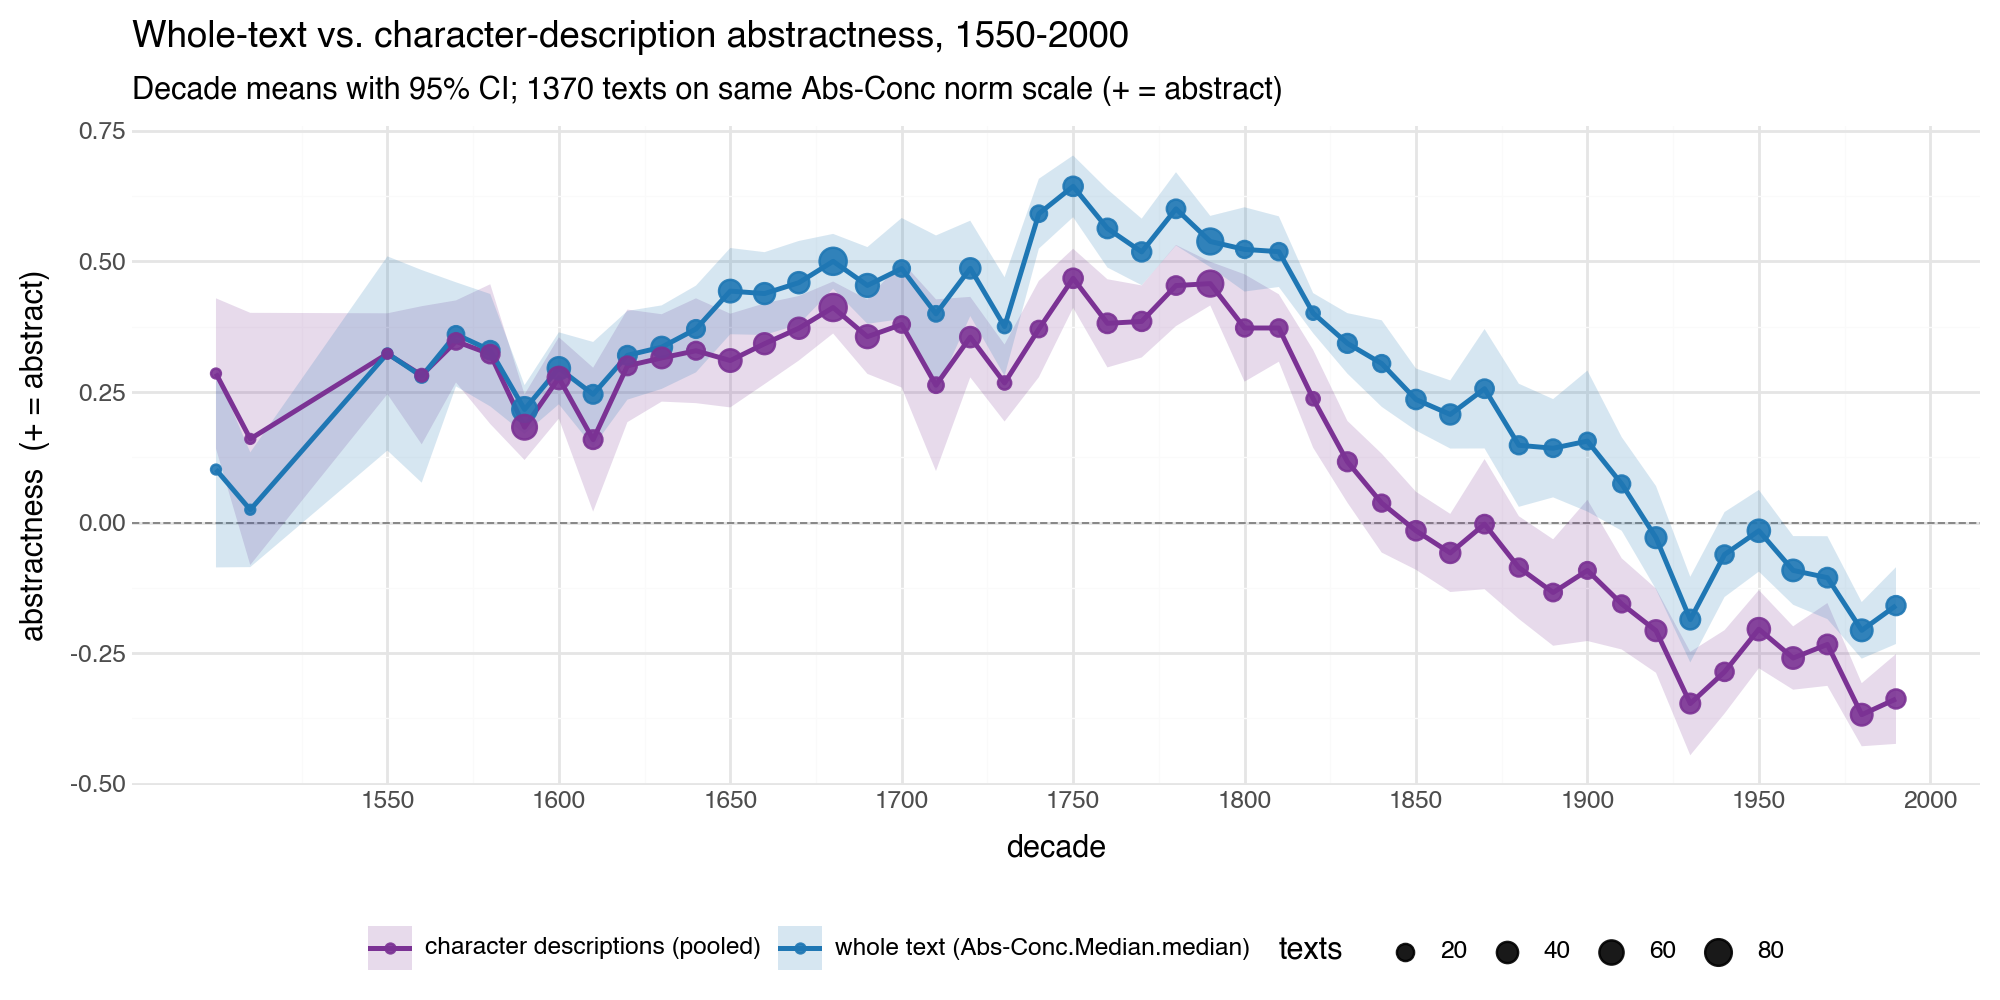

In [13]:
# Compare per-character description abstractness with whole-text abstractness.
# `merged` from §3 already has both: abs_score = -Abs-Conc.Median.median (text)
# and char_desc_conc (pooled char descriptions). Both are on the same norm scale.

DECADE_CMP = 10
MIN_N_CMP = 5
cmp_in = merged[(merged['year'] >= 1500) & (merged['year'] < 2000)
                & merged['abs_score'].notna()
                & merged['char_desc_conc'].notna()].copy()
cmp_in['decade'] = (cmp_in['year'] // DECADE_CMP * DECADE_CMP).astype(int)
cmp_in['desc_abs'] = -cmp_in['char_desc_conc']

def _decade_agg(col):
    g = (cmp_in.groupby('decade')
         .agg(n=('id', 'count'),
              mean=(col, 'mean'),
              se=(col, lambda s: s.std(ddof=1) / np.sqrt(len(s))))
         .query(f'n >= {MIN_N_CMP}')
         .reset_index())
    g['lo'] = g['mean'] - 1.96 * g['se']
    g['hi'] = g['mean'] + 1.96 * g['se']
    return g

agg_text = _decade_agg('abs_score').assign(series='whole text (Abs-Conc.Median.median)')
agg_desc = _decade_agg('desc_abs').assign(series='character descriptions (pooled)')
cmp_long = pd.concat([agg_text, agg_desc], ignore_index=True)

print(f'{len(cmp_in)} texts with both metrics')
print(f'  Pearson correlation (per-text): r = {cmp_in[["abs_score","desc_abs"]].corr().iloc[0,1]:+.3f}')

p_cmp = (p9.ggplot(cmp_long, p9.aes(x='decade', y='mean', color='series', fill='series'))
         + p9.geom_hline(yintercept=0, linetype='dashed', color='#888888', size=0.4)
         + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), alpha=0.18, color=None)
         + p9.geom_line(size=1.0)
         + p9.geom_point(p9.aes(size='n'), alpha=0.9)
         + p9.scale_color_manual(values={'whole text (Abs-Conc.Median.median)': '#1f77b4',
                                         'character descriptions (pooled)': '#7b3294'})
         + p9.scale_fill_manual(values={'whole text (Abs-Conc.Median.median)': '#1f77b4',
                                        'character descriptions (pooled)': '#7b3294'})
         + p9.scale_size_continuous(range=(1.5, 5), name='texts')
         + p9.scale_x_continuous(breaks=range(1550, 2001, 50))
         + p9.labs(
             title='Whole-text vs. character-description abstractness, 1550-2000',
             subtitle=f'Decade means with 95% CI; {len(cmp_in)} texts on same Abs-Conc norm scale (+ = abstract)',
             x='decade',
             y='abstractness  (+ = abstract)',
             color='', fill='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(10, 5), legend_position='bottom'))

out_cmp = os.path.join(DROPBOX_FIGS, 'character_descriptions_vs_text_abstractness.png')
p_cmp.save(out_cmp, dpi=300, verbose=False)
print(f'Saved to {out_cmp}')
p_cmp

## 7. Texts at the extremes

Top realistic-name books and top classical-name books, to sanity-check the heuristic.

In [14]:
cols = ['year', 'author', 'title', 'form', 'n_chars',
        'realistic_pct', 'classical_pct', 'type_pct']
min_chars = 5
filt = df[df['n_chars'] >= min_chars]
print('TOP REALISTIC')
print(filt.nlargest(15, 'realistic_pct')[cols].to_string(index=False))
print()
print('TOP CLASSICAL')
print(filt.nlargest(15, 'classical_pct')[cols].to_string(index=False))
print()
print('TOP TYPE')
print(filt.nlargest(15, 'type_pct')[cols].to_string(index=False))

TOP REALISTIC
 year             author                                              title                                                           form  n_chars  realistic_pct  classical_pct  type_pct
 1954             Austen Lady Susan [in, The Works of Jane Austen; Volume V                                                          novel       14           92.9            0.0       0.0
 1695              Crisp An essay towards the allaying of George Fox his sp                                                       dialogue       11           90.9            0.0       9.1
 1498             Malory                                [Le morte d'Arthur]                                                        romance       24           87.5            0.0       4.2
 1592            Johnson                        The nine worthies of London                                   rogue fiction; romance; tale       23           87.0            0.0       4.3
 1680              Anon.           Q. Elizabet

In [15]:
c.close()